<a href="https://colab.research.google.com/github/Yugsolanki/AIML-Healthcare-Lab/blob/main/8_AIML_Hons_Model_Interpretation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 9.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=59ede76f237c6c974429f51a70fafdd045d84041c7b87cb6e1ca804f5792a647
  Stored in directory: /root/.cache/pip/wheels/fd/a2/af/9ac0a1a85a27f314a06b39e1f492bee1547d52549a4606ed89
Successfully built lime


In [2]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler
from lime import lime_tabular
import shap
from sklearn.datasets import load_breast_cancer
import warnings
warnings.filterwarnings('ignore')

In [3]:
# ===============================
# Data Loading and Preprocessing
# ===============================
def load_and_preprocess_data():
    """
    Load the breast cancer dataset and perform initial preprocessing
    """
    # Load the breast cancer dataset
    data = load_breast_cancer()

    # Create a DataFrame
    df = pd.DataFrame(data.data, columns=data.feature_names)
    df['target'] = data.target

    # Split features and target
    X = df.drop('target', axis=1)
    y = df['target']

    # Split the data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Scale the features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    return X_train_scaled, X_test_scaled, y_train, y_test, df, X_train, X_test

In [4]:
# ===============================
# Data Analysis
# ===============================
def perform_data_analysis(df):
    """
    Perform exploratory data analysis and generate visualizations
    """
    # Basic statistics
    print("\nBasic Statistics:")
    print(df.describe())

    # Correlation analysis
    plt.figure(figsize=(12, 8))
    sns.heatmap(df.corr(), cmap='coolwarm', center=0)
    plt.title('Feature Correlation Heatmap')
    plt.tight_layout()
    plt.show()

    # Distribution of target variable
    plt.figure(figsize=(8, 6))
    sns.countplot(data=df, x='target')
    plt.title('Distribution of Target Variable (0: Malignant, 1: Benign)')
    plt.show()

    # Feature distributions
    plt.figure(figsize=(15, 10))
    for i, column in enumerate(df.columns[:5], 1):
        plt.subplot(2, 3, i)
        sns.histplot(data=df, x=column, hue='target', bins=30, alpha=0.6)
        plt.title(f'Distribution of {column}')
    plt.tight_layout()
    plt.show()

In [5]:
# ===============================
# Model Training
# ===============================
def train_model(X_train_scaled, y_train):
    """
    Train a Random Forest model
    """
    model = RandomForestClassifier(n_estimators=100, random_state=42)
    model.fit(X_train_scaled, y_train)
    return model

In [6]:
# ===============================
# Model Explanation with LIME
# ===============================
def explain_with_lime(model, X_train, X_test, feature_names):
    """
    Generate LIME explanations for a test instance
    """
    # Create a LIME explainer
    explainer = lime_tabular.LimeTabularExplainer(
        X_train,
        feature_names=feature_names,
        class_names=['Malignant', 'Benign'],
        mode='classification'
    )

    # Explain a test instance
    exp = explainer.explain_instance(
        X_test[0],
        model.predict_proba,
        num_features=10
    )

    # Plot the explanation
    plt.figure(figsize=(10, 6))
    exp.as_pyplot_figure()
    plt.title('LIME Explanation for Test Instance')
    plt.tight_layout()
    plt.show()

In [7]:
# ===============================
# Model Explanation with SHAP
# ===============================
def explain_with_shap(model, X_train_scaled, X_test_scaled, feature_names):
    """
    Generate SHAP explanations for the model
    """
    # Create SHAP explainer
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_test_scaled)

    # Summary plot
    plt.figure(figsize=(10, 8))
    shap.summary_plot(shap_values[1], X_test_scaled, feature_names=feature_names)
    plt.title('SHAP Summary Plot')
    plt.tight_layout()
    plt.show()

    # Force plot for a single prediction
    plt.figure(figsize=(12, 4))
    shap.force_plot(
        explainer.expected_value[1],
        shap_values[1][0],
        X_test_scaled[0],
        feature_names=feature_names,
        matplotlib=True
    )
    plt.title('SHAP Force Plot for Single Prediction')
    plt.tight_layout()
    plt.show()

In [8]:
# ===============================
# Feature Importance Analysis
# ===============================
def analyze_feature_importance(model, feature_names):
    """
    Analyze and visualize feature importance
    """
    # Get feature importance
    importance = model.feature_importances_

    # Create DataFrame for visualization
    feat_importance = pd.DataFrame({
        'feature': feature_names,
        'importance': importance
    })
    feat_importance = feat_importance.sort_values('importance', ascending=False)

    # Plot feature importance
    plt.figure(figsize=(12, 6))
    sns.barplot(data=feat_importance.head(10), x='importance', y='feature')
    plt.title('Top 10 Most Important Features')
    plt.xlabel('Feature Importance')
    plt.tight_layout()
    plt.show()

In [9]:
# Load and preprocess data
X_train_scaled, X_test_scaled, y_train, y_test, df, X_train, X_test = load_and_preprocess_data()


Basic Statistics:
       mean radius  mean texture  mean perimeter    mean area  \
count   569.000000    569.000000      569.000000   569.000000   
mean     14.127292     19.289649       91.969033   654.889104   
std       3.524049      4.301036       24.298981   351.914129   
min       6.981000      9.710000       43.790000   143.500000   
25%      11.700000     16.170000       75.170000   420.300000   
50%      13.370000     18.840000       86.240000   551.100000   
75%      15.780000     21.800000      104.100000   782.700000   
max      28.110000     39.280000      188.500000  2501.000000   

       mean smoothness  mean compactness  mean concavity  mean concave points  \
count       569.000000        569.000000      569.000000           569.000000   
mean          0.096360          0.104341        0.088799             0.048919   
std           0.014064          0.052813        0.079720             0.038803   
min           0.052630          0.019380        0.000000             0.

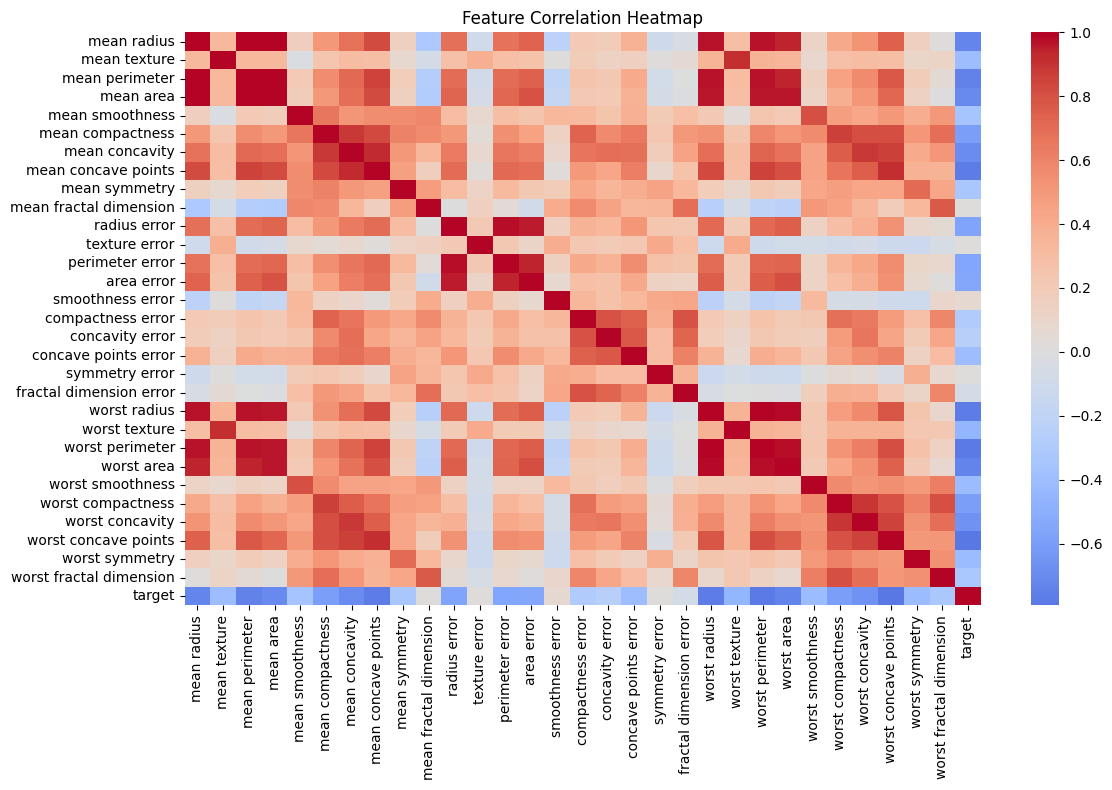

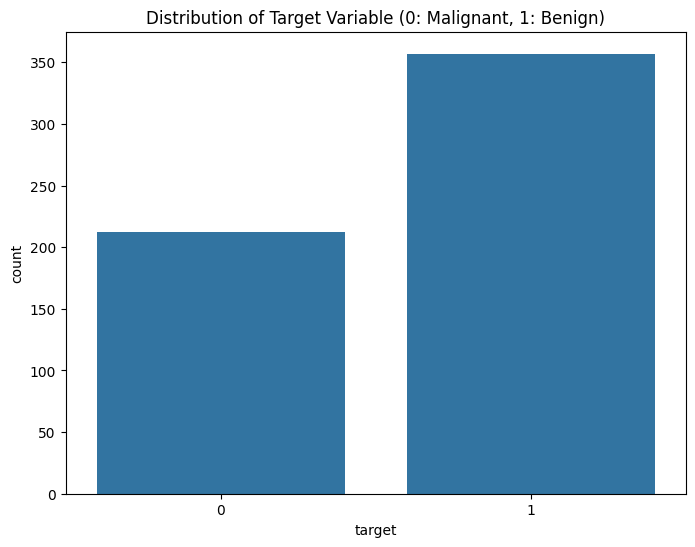

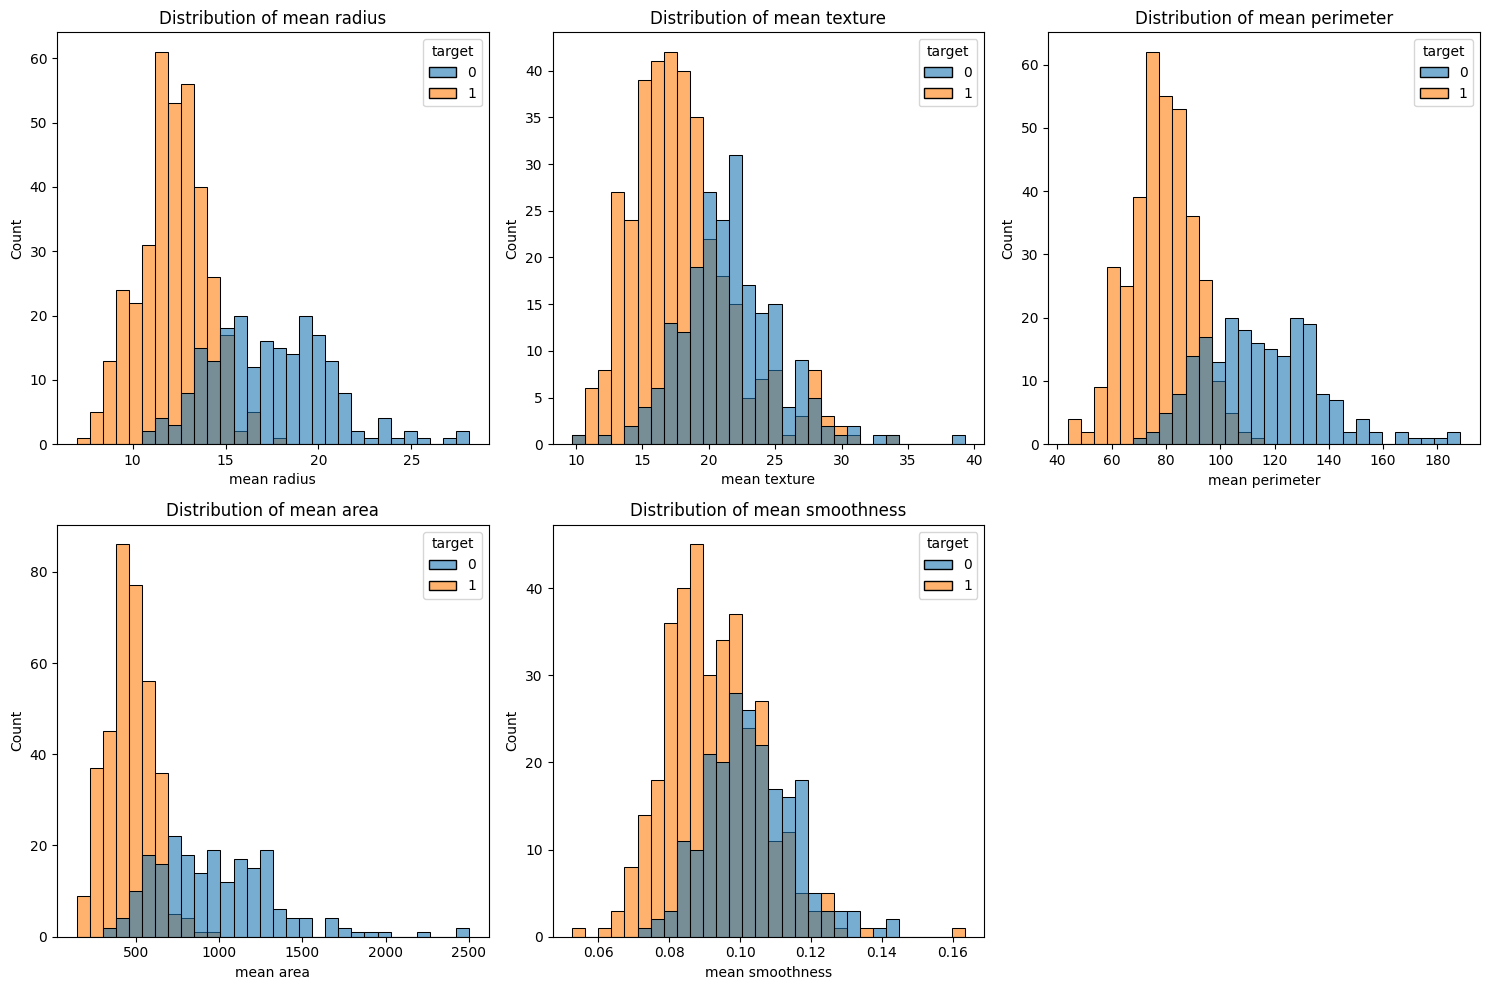

In [10]:
# Perform data analysis
perform_data_analysis(df)

In [11]:
# Train model
model = train_model(X_train_scaled, y_train)

In [12]:
# Make predictions
y_pred = model.predict(X_test_scaled)

In [13]:
# Print model performance
print("\nModel Performance:")
print(classification_report(y_test, y_pred))


Model Performance:
              precision    recall  f1-score   support

           0       0.98      0.93      0.95        43
           1       0.96      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



In [14]:
# Generate explanations
feature_names = df.drop('target', axis=1).columns

<Figure size 1000x600 with 0 Axes>

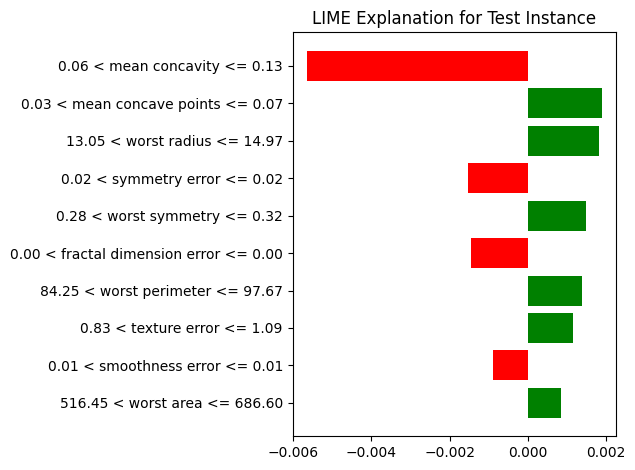

In [15]:
# explain_with_lime(model, X_train, X_test, feature_names)
explain_with_lime(model, X_train.values, X_test.values, feature_names) # Convert X_train and X_test to NumPy arrays using .values

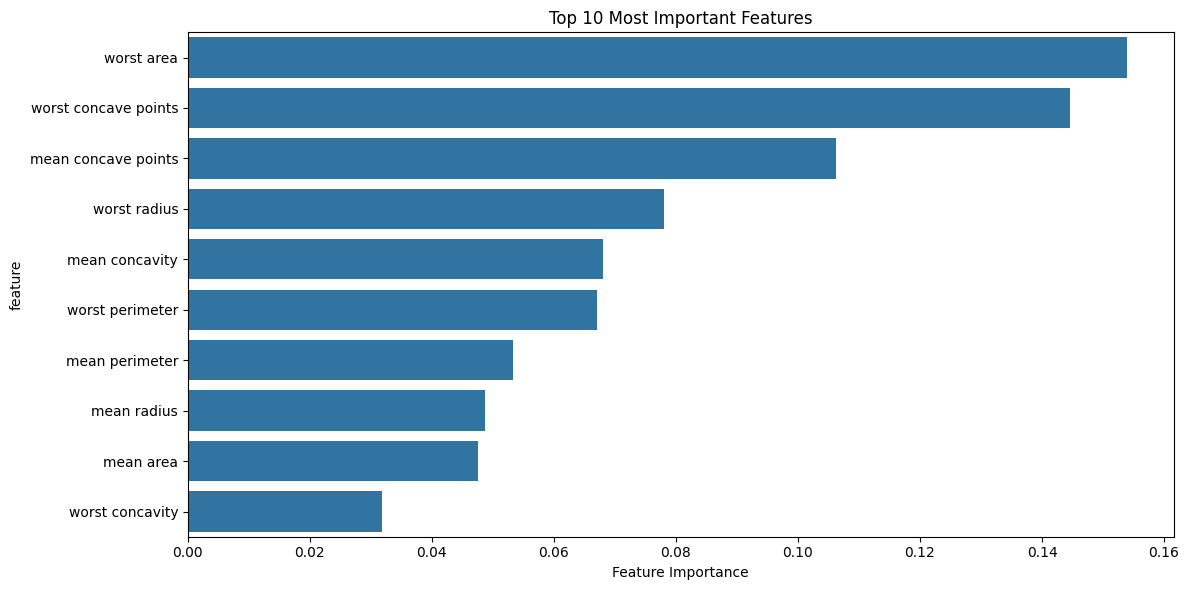

In [16]:
analyze_feature_importance(model, feature_names)

In [19]:
df.columns.values

array(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error',
       'fractal dimension error', 'worst radius', 'worst texture',
       'worst perimeter', 'worst area', 'worst smoothness',
       'worst compactness', 'worst concavity', 'worst concave points',
       'worst symmetry', 'worst fractal dimension', 'target'],
      dtype=object)

In [20]:
# Assuming 'num' is your target variable with 5 classes (0, 1, 2, 3, 4)
# If it's different, adjust the class_index accordingly

class_index = 4  # Choose the class you want to analyze (e.g., 0 for the first class)

shap.dependence_plot(
    "mean radius",
    shap_values.values[:, :, class_index],  # Select SHAP values for the specific class
    X_test
)

NameError: name 'shap_values' is not defined